<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_11_Clinical_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd



In [ ]:
#Create Clinical Dataset
import pandas as pd

data = {
"Patient_ID": ["P001", "P002", "P003", "P003"],
"Age": [56, 60,np.nan, 45],
"Gender": ["Male", "Female", "M", "M"],
"Tumor_Size": [4.5, np.nan, 5.1, 5.1]
}
df= pd.DataFrame(data)
print("Original Dataset:\n", df)

Original Dataset:
   Patient_ID   Age  Gender  Tumor_Size
0       P001  56.0    Male         4.5
1       P002  60.0  Female         NaN
2       P003   NaN       M         5.1
3       P003  45.0       M         5.1


In [ ]:
# How to remove duplictes
df= df.drop_duplicates()
print("After removing duplicates\n",df)

After removing duplicates
   Patient_ID  Age  Gender  Tumor_Size
0       P001   56    Male         4.5
1       P002   60  Female         3.2
2       P003   45       M         5.1


In [ ]:
#How to standardize data
df["Gender"] = df["Gender"].str.lower()
df["Gender"] = df["Gender"].replace({
    "male":"M",
    "female":"F"
})
print("Standardized:\n",df)

Standardized:
   Patient_ID  Age Gender  Tumor_Size
0       P001   56      M         4.5
1       P002   60      F         3.2
2       P003   45      m         5.1


In [ ]:
#Handling impossible values
import numpy as np
data ={
    "Patient ID": ["P001","P002","P003"],
    "Age": [56,-5,72],
    "Cholesterol": [210,800,190]
}
df = pd.DataFrame(data)
print("Before Cleaning: \n",df)

Before Cleaning: 
   Patient ID  Age  Cholesterol
0       P001   56          210
1       P002   -5          800
2       P003   72          190


In [ ]:
#Fix impossible value
df.loc[df["Age"]<0,"Age"] = np.nan
print("After Cleaning:\n", df)

After Cleaning:
   Patient ID   Age  Cholesterol
0       P001  56.0          210
1       P002   NaN          800
2       P003  72.0          190


In [ ]:
# Check for missing values
df = pd.DataFrame(data)

print(df)
print("Missing per coloumn:",df.isnull().sum())

  Patient_ID   Age  Gender  Tumor_Size
0       P001  56.0    Male         4.5
1       P002  60.0  Female         NaN
2       P003   NaN       M         5.1
3       P003  45.0       M         5.1
Missing per coloumn: Patient_ID    0
Age           1
Gender        0
Tumor_Size    1
dtype: int64


In [ ]:
#Substitute data using mean vs median imputation
df["Age"].fillna(df["Age"].mean().inplace=True)
print("Mean Imputed:\n",df)


Mean Imputed:
   Patient_ID        Age  Gender  Tumor_Size
0       P001  56.000000    Male         4.5
1       P002  60.000000  Female         NaN
2       P003  53.666667       M         5.1
3       P003  45.000000       M         5.1


/tmp/ipykernel_9032/41485958.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [ ]:
#Reset Dataset first for median imputation
data = {
    "Tumor_Size" : [2.1,2.5,2.8,3.0,15.0]
}
df = pd.DataFrame(data)
print("Mean:",df["Tumor_Size"].mean())
print("Mean:",df["Tumor_Size"].median())


Mean: 5.08
Mean: 2.8


In [ ]:
#KKN imputaton before
data = {
    "Age": [50,60,55,np.nan],
    "Tumor_Size":[3.2,4.1,3.8,3.5],
    "Cholestrol":[200,220,210,205]

}
df = pd.DataFrame(data)
print(df)

    Age  Tumor_Size  Cholestrol
0  50.0         3.2         200
1  60.0         4.1         220
2  55.0         3.8         210
3   NaN         3.5         205


In [ ]:
#KKN imputaton after machine learning
from sklearn.impute import KNNImputer
imputer  = KNNImputer(n_neighbors=2)
df_imputed = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)
print("After KNNI Imputation:\n",df_imputed)


After KNNI Imputation:
     Age  Tumor_Size  Cholestrol
0  50.0         3.2       200.0
1  60.0         4.1       220.0
2  55.0         3.8       210.0
3  52.5         3.5       205.0


In [ ]:
#Encoding and Scaling Data
 # Encoding Categorial Data
data = {
     "Stage" : ["I","II","III","II"]
 }
df = pd.DataFrame(data)
df_encoded = pd.get_dummies(df,columns=["Stage"])
print(df_encoded)


   Stage_I  Stage_II  Stage_III
0     True     False      False
1    False      True      False
2    False     False       True
3    False      True      False


In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
data  = {
    "Age": [25,50,75],
    "Tumor_size": [2,5,10]
}
df = pd.DataFrame(data)
scaler = StandardScaler()
scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled, columns = df.columns)
print(df_scaled)

        Age  Tumor_size
0 -1.224745   -1.111168
1  0.000000   -0.202031
2  1.224745    1.313198


In [ ]:
#Detect the outliers
import pandas as pd
import numpy as np

data ={
    "Patient_ID": ["P001","P002","P003","P004","P005"],
    "Tumor_size": [2.5,3.0,2.8,50.0,3.2]  # 50 is extreme or outlier
}
df= pd.DataFrame(data)
print(df)


  Patient_ID  Tumor_size
0       P001         2.5
1       P002         3.0
2       P003         2.8
3       P004        50.0
4       P005         3.2


In [ ]:
data ={
    "Patient_ID": ["P001","P002","P003","P004","P005"],
    "Tumor_Size": [2.5,3.0,2.8,50.0,3.2]  # 50 is extreme or outlier
}
df= pd.DataFrame(data)
Q1= df["Tumor_Size"].quantile(0.25)
Q3 =df["Tumor_Size"].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
outliers = df[df["Tumor_Size"]<lower]|(df["Tumor_Size"]>upper)
print("Detected Outliers:",outliers)

Detected Outliers: Empty DataFrame
Columns: [Patient_ID, Tumor_Size, 0, 1, 2, 3, 4]
Index: []


In [ ]:
!pip install matplotlib


In [ ]:
#Missing Data Pattern recognization
data = {
    "Age": [56,np.nan,45,67,np.nan],
    "Tumor_Size": [4.5,3.2,np.nan,5.1,4.8],
    "Cholestrol":[210,180,195,np.nan,200]
}
df= pd.DataFrame(data)
print(df)

    Age  Tumor_Size  Cholestrol
0  56.0         4.5       210.0
1   NaN         3.2       180.0
2  45.0         NaN       195.0
3  67.0         5.1         NaN
4   NaN         4.8       200.0


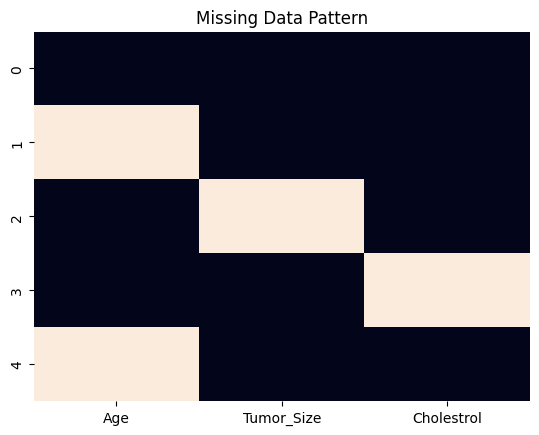

In [ ]:
#Visualize Missing Pattern
import Seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Data Pattern")
plt.show()

In [ ]:
#when not to drop missing data
data ={
    "Patient_ID": ["P001","P002","P003","P004"],
    "Survival_Months": [24,36,np.nan,18],
    "Event":[1,0,1,1] # 1- death, 0- censored
}
df=pd.DataFrame(data)
print(df)


  Patient_ID  Survival_Months  Event
0       P001             24.0      1
1       P002             36.0      0
2       P003              NaN      1
3       P004             18.0      1


In [ ]:
df_drop = df.dropna()
print(df_drop)

  Patient_ID  Survival_Months  Event
0       P001             24.0      1
1       P002             36.0      0
3       P004             18.0      1


In [ ]:
# Avoid data leakage
#Imputation should happen after the train test split
data ={
    "Age":[50,60,55,np.nan,65,70],
    "Tumor_Size":[3.2,4.1,3.8,3.5,4.5,5.0],
    "Response":[1,0,1,1,0,0]
}
df = pd.DataFrame(data)
# Wrong way to imputate before split
# df["Age"].fillna(df["Age"].mean(),inplace=True)
# This leaks data from the test set so the correct way is

X = df[["Age","Tumor_Size"]]
Y = df["Response"]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)
#Impute only on training data
train_mean = X_train["Age"].mean()
X_train["Age"].fillna(train_mean,inplace=True)

#Use same mean for test data

X_test["Age"].fillna(train_mean,inplace=True)



/tmp/ipykernel_9032/3934083135.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["Age"].fillna(train_mean,inplace=True)
/tmp/ipykernel_9032/3934083135.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
print("X_train after imputation:\n", X_train)
print("\nX_test after imputation:\n", X_test)
print("\nY_train:\n", Y_train)
print("\nY_test:\n", Y_test)

X_train after imputation:
          Age  Tumor_Size
4  65.000000         4.5
3  61.666667         3.5
5  70.000000         5.0
0  50.000000         3.2

X_test after imputation:
     Age  Tumor_Size
1  60.0         4.1
2  55.0         3.8

Y_train:
 4    0
3    1
5    0
0    1
Name: Response, dtype: int64

Y_test:
 1    0
2    1
Name: Response, dtype: int64


In [ ]:
#Encoding Ordinal Clinical Stages
#Cancer stage has order  Stage I< Stage II < Stage III < Stage IV
data ={
    "Stage": ["I","II","III","IV"]
}
df = pd.DataFrame(data)
print(df)

# Ordinal Encoding
stage_mapping = {"I": 1, "II": 2, "III": 3, "IV": 4} # Use a dictionary for mapping stages to numerical values
df["Stage_Encoded"] = df["Stage"].map(stage_mapping)
print(df)

  Stage
0     I
1    II
2   III
3    IV
  Stage  Stage_Encoded
0     I              1
1    II              2
2   III              3
3    IV              4
